In [1]:
# %pip install numpy torch torchvision scikit-learn matplotlib pillow 
import os
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm

import matplotlib.pyplot as plt # For data viz
import pandas as pd
import numpy as np
import sys
from tqdm.notebook import tqdm

print('System Version:', sys.version)
print('PyTorch version', torch.__version__)
print('Torchvision version', torchvision.__version__)
print('Numpy version', np.__version__)
print('Pandas version', pd.__version__)

System Version: 3.12.8 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:48:34) [MSC v.1929 64 bit (AMD64)]
PyTorch version 2.3.1
Torchvision version 0.18.1a0
Numpy version 1.26.4
Pandas version 2.2.2


In [2]:
class SpectrogramImagesDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = ImageFolder(data_dir, transform=transform)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]
    
    @property
    def classes(self):
        return self.data.classes

In [3]:
dataset = SpectrogramImagesDataset(
    data_dir= r'D:\DroneSwarmsImages\Wavelet_Plots\Scalogram_Dataset_MIX\train'
)

In [4]:
len(dataset)

4506

0


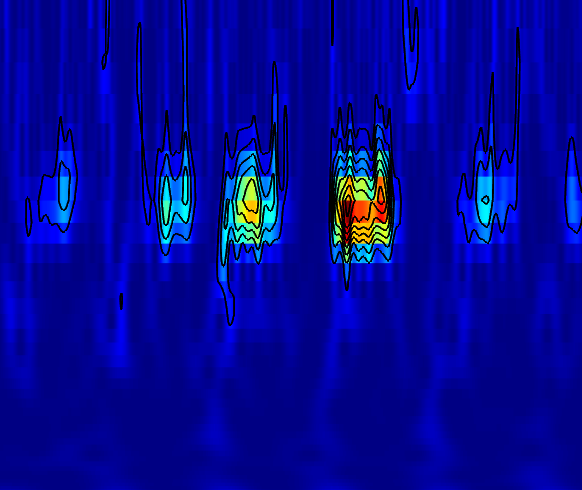

In [5]:
image, label = dataset[125]
print(label)
image

In [6]:
# Get a dictionary associating target values with folder names
data_dir =  r'D:\DroneSwarmsImages\Wavelet_Plots\Scalogram_Dataset_MIX\train'
target_to_class = {v: k for k, v in ImageFolder(data_dir).class_to_idx.items()}
print(target_to_class)

{0: 'mavic2', 1: 'mavic3', 2: 'mavic3_mavic2', 3: 'phantom4', 4: 'phantom4_mavic2', 5: 'phantom4_mavic3'}


In [14]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

data_dir = r'D:\DroneSwarmsImages\Wavelet_Plots\Scalogram_Dataset_MIX\train'
dataset = SpectrogramImagesDataset(data_dir, transform)

In [16]:
# Model definitions using VGG16 and VGG19
class CustomVGG(nn.Module):
    def __init__(self, base_model, num_classes):
        super(CustomVGG, self).__init__()
        self.features = base_model.features
        self.avgpool = base_model.avgpool
        self.classifier = nn.Sequential(
            nn.Linear(base_model.classifier[0].in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Initialize models
# vgg16_base = models.vgg16(pretrained=True)
# for param in vgg16_base.parameters():
#     param.requires_grad = False
# model_vgg16 = CustomVGG(vgg16_base, num_classes=5)

vgg19_base = models.vgg19(pretrained=True)
for param in vgg19_base.parameters():
    param.requires_grad = False
model_vgg19 = CustomVGG(vgg19_base, num_classes=6)

In [17]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

data_dir =  r'D:\DroneSwarmsImages\Wavelet_Plots\Scalogram_Dataset_MIX\train'
dataset = SpectrogramImagesDataset(data_dir, transform)

In [18]:
# Correct folder paths
train_folder = r'D:\DroneSwarmsImages\Wavelet_Plots\Scalogram_Dataset_MIX\train'
valid_folder =  r'D:\DroneSwarmsImages\Wavelet_Plots\Scalogram_Dataset_MIX\valid'
test_folder = r'D:\DroneSwarmsImages\Wavelet_Plots\Scalogram_Dataset_MIX\test'

In [20]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


train_dataset = SpectrogramImagesDataset(train_folder, transform=transform)
val_dataset = SpectrogramImagesDataset(valid_folder, transform=transform)
test_dataset = SpectrogramImagesDataset(test_folder, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [21]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_vgg19.to(device)

CustomVGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1)

In [22]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
#optimizer_vgg16 = optim.Adam(model_vgg16.classifier.parameters(), lr=0.0001)
optimizer_vgg19 = optim.Adam(model_vgg19.classifier.parameters(), lr=0.0001)

In [23]:
#from tqdm import tqdm

scheduler_vgg19 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_vgg19, mode='min', factor=0.5, patience=2, min_lr=1e-7, verbose=True)

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=5):
    model.train()
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        running_corrects = 0
        
        # Use tqdm for progress bar
        train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for images, labels in train_loader_tqdm:
            images = images.to(device)
            labels = labels.to(device, dtype=torch.long)
            
            optimizer.zero_grad()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
            # Update tqdm with the current loss
            train_loader_tqdm.set_postfix(loss=loss.item())

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")
        
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device, dtype=torch.long)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * images.size(0)
                val_corrects += torch.sum(preds == labels.data)
        
        val_loss /= len(val_loader.dataset)
        val_acc = val_corrects.double() / len(val_loader.dataset)
        print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")
        
        scheduler.step(val_loss)
        
        # Save the best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"best_model_{model.__class__.__name__}.pt")
        
        model.train()


d:\Softwares\envs\Anaconda_Projects\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [24]:
train_model(model_vgg19, train_loader, val_loader, criterion, optimizer_vgg19, scheduler_vgg19)

Epoch 1/5:   0%|          | 0/564 [00:00<?, ?it/s]

Epoch [1/5], Loss: 0.6603, Accuracy: 0.7570
Validation Loss: 0.3712, Accuracy: 0.8676


Epoch 2/5:   0%|          | 0/564 [00:00<?, ?it/s]

Epoch [2/5], Loss: 0.3192, Accuracy: 0.8913
Validation Loss: 0.2720, Accuracy: 0.8951


Epoch 3/5:   0%|          | 0/564 [00:00<?, ?it/s]

Epoch [3/5], Loss: 0.2322, Accuracy: 0.9083
Validation Loss: 0.2404, Accuracy: 0.9017


Epoch 4/5:   0%|          | 0/564 [00:00<?, ?it/s]

Epoch [4/5], Loss: 0.1900, Accuracy: 0.9263
Validation Loss: 0.2188, Accuracy: 0.8993


Epoch 5/5:   0%|          | 0/564 [00:00<?, ?it/s]

Epoch [5/5], Loss: 0.1600, Accuracy: 0.9374
Validation Loss: 0.2108, Accuracy: 0.9051


                 precision    recall  f1-score   support

         mavic2       0.93      1.00      0.96        50
         mavic3       0.98      0.94      0.96        50
  mavic3_mavic2       1.00      0.94      0.97        50
       phantom4       0.96      0.94      0.95        51
phantom4_mavic2       0.82      0.80      0.81        50
phantom4_mavic3       0.81      0.86      0.83        50

       accuracy                           0.91       301
      macro avg       0.92      0.91      0.91       301
   weighted avg       0.92      0.91      0.91       301



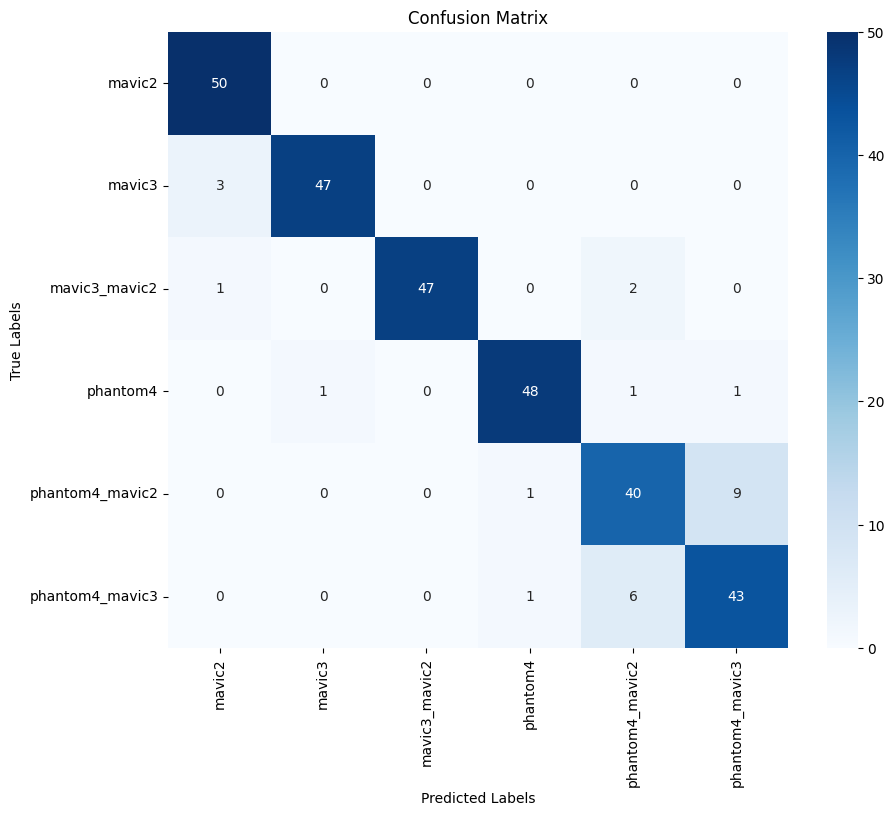

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torchvision import datasets
import os
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
def test_model(model, test_loader, target_to_class, checkpoint_path, device):
    """
    Tests a model, generates a classification report, and plots a confusion matrix using class names.
    
    Parameters:
    - model: The PyTorch model to test.
    - test_loader: DataLoader for the test set.
    - target_to_class: Dictionary mapping numeric class indices to class names.
    - checkpoint_path: Path to the saved model checkpoint.
    - device: Device to run the model on (CPU or GPU).
    
    Returns:
    - classification_report: A string representation of the classification report.
    - confusion_matrix: The confusion matrix as a 2D numpy array.
    """
    # Load model weights
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device, dtype=torch.long)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Generate classification report
    class_names = [target_to_class[idx] for idx in range(len(target_to_class))]
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print(report)
    
    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()
    
    return report, cm

# Example Usage:
# Assuming `test_loader` is already defined, `model_vgg19` is your model, and device is 'cuda' or 'cpu'.

data_dir = r'D:\DroneSwarmsImages\Wavelet_Plots\Scalogram_Dataset_MIX\test'
target_to_class = {v: k for k, v in ImageFolder(data_dir).class_to_idx.items()}

checkpoint_path = "best_model_CustomVGG.pt"
report, cm = test_model(model_vgg19, test_loader, target_to_class, checkpoint_path, device=device)


              precision    recall  f1-score   support

     Class 0       0.99      0.99      0.99       200
     Class 1       1.00      0.98      0.99       200
     Class 2       1.00      1.00      1.00       201

    accuracy                           0.99       601
   macro avg       0.99      0.99      0.99       601
weighted avg       0.99      0.99      0.99       601



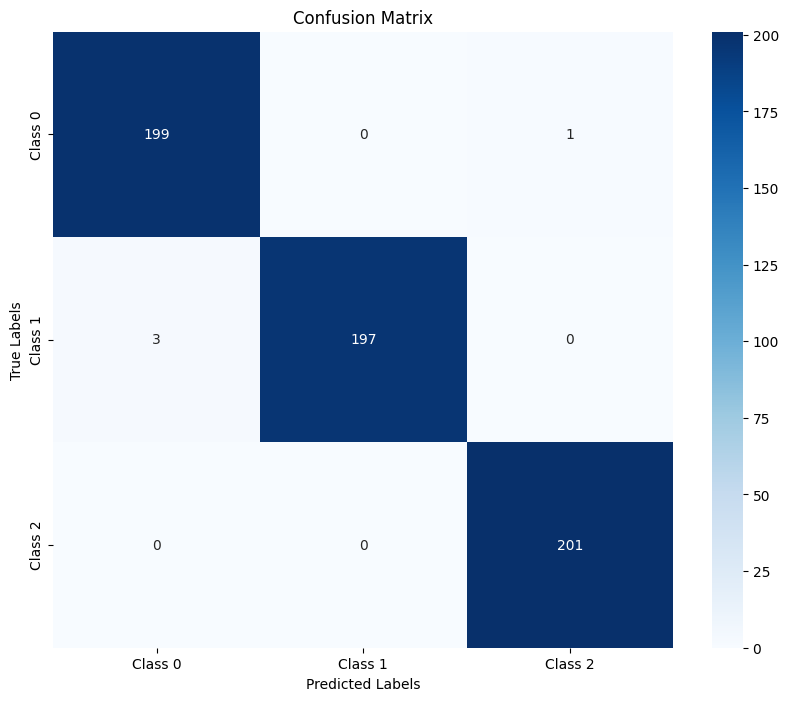

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torchvision import transforms, datasets
import os

def test_model(model, test_loader, num_classes, checkpoint_path, device):
    """
    Tests a model, generates a classification report, and plots a confusion matrix.
    
    Parameters:
    - model: The PyTorch model to test.
    - test_loader: DataLoader for the test set.
    - num_classes: Number of classes in the dataset.
    - checkpoint_path: Path to the saved model checkpoint.
    - device: Device to run the model on (CPU or GPU).
    
    Returns:
    - classification_report: A string representation of the classification report.
    - confusion_matrix: The confusion matrix as a 2D numpy array.
    """
    # Load model weights
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device, dtype=torch.long)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Generate classification report
    class_names = [f"Class {i}" for i in range(num_classes)]
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print(report)
    
    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()
    
    return report, cm

# Example Usage:
# Assuming `test_loader` is already defined, `model_vgg19` is your model, and device is 'cuda' or 'cpu'.
checkpoint_path = "best_model_CustomVGG.pt"
report, cm = test_model(model_vgg19, test_loader, num_classes=3, checkpoint_path=checkpoint_path, device=device)


In [48]:
import torch
from torchvision import transforms
from PIL import Image
import os

# Define a function to perform inference on a single image
def infer_single_image(model, image_path, checkpoint_path, device):
    # Load model weights
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()

    # Define transformation (same as the one used during training)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Resize to match model input size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)

    return pred.cpu().numpy()[0]

# Define a function to perform inference on all images in a directory
def infer_from_directory(model, dir_path, checkpoint_path, device):
    predictions = {}
    for root, _, files in os.walk(dir_path):
        for file in files:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                image_path = os.path.join(root, file)
                pred = infer_single_image(model, image_path, checkpoint_path, device)
                predictions[image_path] = pred
                print(f'Predicted class for {file}: {pred}')
    return predictions

# Example Usage:
test_dir = r'D:\FYP-SignalProcessing\DroneSwarmsImages\Wavelet_Plots\Scalogram_Dataset\test_1'
checkpoint_path = "best_model_CustomVGG.pt"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
all_predictions = infer_from_directory(model_vgg19, test_dir, checkpoint_path, device)


Predicted class for imag45_wavelet1_magnitude_moving.png: 2
Predicted class for imag45_wavelet1_magnitud_stationary.png: 2
Predicted class for imag45_wavelet2_magnitude_moving.png: 2
Predicted class for imag45_wavelet2_magnitud_stationary.png: 2
Predicted class for imag45_wavelet3_magnitude_moving.png: 2
Predicted class for imag45_wavelet3_magnitud_stationary.png: 2
Predicted class for imag45_wavelet4_magnitude_moving.png: 2
Predicted class for imag45_wavelet4_magnitud_stationary.png: 2
Predicted class for imag45_wavelet5_magnitude_moving.png: 2
Predicted class for imag45_wavelet5_magnitud_stationary.png: 2
Predicted class for imag45_wavelet6_magnitude_moving.png: 2
Predicted class for imag45_wavelet6_magnitud_stationary.png: 2
Predicted class for imag45_wavelet7_magnitude_moving.png: 2
Predicted class for imag45_wavelet7_magnitud_stationary.png: 2
Predicted class for imag45_wavelet8_magnitude_moving.png: 2
Predicted class for imag45_wavelet8_magnitud_stationary.png: 2


In [ ]:

import torch
from torchvision import transforms
from PIL import Image
import os

# Define a function to perform inference on a single image
def infer_single_image(model, image_path, checkpoint_path, device):
    # Load model weights
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()

    # Define transformation (same as the one used during training)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Resize to match model input size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)

    return pred.cpu().numpy()[0]

# Define a function to perform inference on all images in a directory
def infer_from_directory(model, dir_path, checkpoint_path, device):
    predictions = {}
    for root, _, files in os.walk(dir_path):
        for file in files:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                image_path = os.path.join(root, file)
                pred = infer_single_image(model, image_path, checkpoint_path, device)
                predictions[image_path] = pred
                print(f'Predicted class for {file}: {pred}')
    return predictions

# Example Usage:
test_dir = r'D:\FYP-SignalProcessing\DroneSwarmsImages\Wavelet_Plots\hexacopter_test'
checkpoint_path = "best_model_CustomVGG.pt"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
all_predictions = infer_from_directory(model_vgg19, test_dir, checkpoint_path, device)


Predicted class for imag1_wavelet1_magnitud.png: 2
Predicted class for imag1_wavelet2_magnitud.png: 2
Predicted class for imag1_wavelet3_magnitud.png: 2
Predicted class for imag1_wavelet4_magnitud.png: 2
Predicted class for imag1_wavelet5_magnitud.png: 2
Predicted class for imag1_wavelet6_magnitud.png: 2
Predicted class for imag1_wavelet7_magnitud.png: 2
Predicted class for imag1_wavelet8_magnitud.png: 2
Predicted class for imag2_wavelet1_magnitud.png: 2
Predicted class for imag2_wavelet2_magnitud.png: 2
Predicted class for imag2_wavelet3_magnitud.png: 2
Predicted class for imag2_wavelet4_magnitud.png: 2
Predicted class for imag2_wavelet5_magnitud.png: 2
Predicted class for imag2_wavelet6_magnitud.png: 2
Predicted class for imag2_wavelet7_magnitud.png: 2
Predicted class for imag2_wavelet8_magnitud.png: 2
Predicted class for imag3_wavelet1_magnitud.png: 2
Predicted class for imag3_wavelet2_magnitud.png: 2
Predicted class for imag3_wavelet3_magnitud.png: 2
Predicted class for imag3_wavel

In [50]:

import torch
from torchvision import transforms
from PIL import Image
import os

# Define a function to perform inference on a single image
def infer_single_image(model, image_path, checkpoint_path, device):
    # Load model weights
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()

    # Define transformation (same as the one used during training)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Resize to match model input size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)

    return pred.cpu().numpy()[0]

# Define a function to perform inference on all images in a directory
def infer_from_directory(model, dir_path, checkpoint_path, device):
    predictions = {}
    for root, _, files in os.walk(dir_path):
        for file in files:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                image_path = os.path.join(root, file)
                pred = infer_single_image(model, image_path, checkpoint_path, device)
                predictions[image_path] = pred
                print(f'Predicted class for {file}: {pred}')
    return predictions

# Example Usage:
test_dir = r'D:\FYP-SignalProcessing\DroneSwarmsImages\Wavelet_Plots\smartdrone_test'
checkpoint_path = "best_model_CustomVGG.pt"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
all_predictions = infer_from_directory(model_vgg19, test_dir, checkpoint_path, device)


Predicted class for imag1_wavelet1_magnitud.png: 1
Predicted class for imag1_wavelet2_magnitud.png: 2
Predicted class for imag1_wavelet3_magnitud.png: 1
Predicted class for imag1_wavelet4_magnitud.png: 2
Predicted class for imag1_wavelet5_magnitud.png: 0
Predicted class for imag1_wavelet6_magnitud.png: 0
Predicted class for imag1_wavelet7_magnitud.png: 2
Predicted class for imag1_wavelet8_magnitud.png: 2
Predicted class for imag2_wavelet1_magnitud.png: 0
Predicted class for imag2_wavelet2_magnitud.png: 1
Predicted class for imag2_wavelet3_magnitud.png: 1
Predicted class for imag2_wavelet4_magnitud.png: 2
Predicted class for imag2_wavelet5_magnitud.png: 0
Predicted class for imag2_wavelet6_magnitud.png: 1
Predicted class for imag2_wavelet7_magnitud.png: 1
Predicted class for imag2_wavelet8_magnitud.png: 2
Predicted class for imag3_wavelet1_magnitud.png: 1
Predicted class for imag3_wavelet2_magnitud.png: 1
Predicted class for imag3_wavelet3_magnitud.png: 1
Predicted class for imag3_wavel

In [51]:

import torch
from torchvision import transforms
from PIL import Image
import os

# Define a function to perform inference on a single image
def infer_single_image(model, image_path, checkpoint_path, device):
    # Load model weights
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()

    # Define transformation (same as the one used during training)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Resize to match model input size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)

    return pred.cpu().numpy()[0]

# Define a function to perform inference on all images in a directory
def infer_from_directory(model, dir_path, checkpoint_path, device):
    predictions = {}
    for root, _, files in os.walk(dir_path):
        for file in files:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                image_path = os.path.join(root, file)
                pred = infer_single_image(model, image_path, checkpoint_path, device)
                predictions[image_path] = pred
                print(f'Predicted class for {file}: {pred}')
    return predictions

# Example Usage:
test_dir = r'D:\FYP-SignalProcessing\DroneSwarmsImages\Wavelet_Plots\phantom4IT_test'
checkpoint_path = "best_model_CustomVGG.pt"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
all_predictions = infer_from_directory(model_vgg19, test_dir, checkpoint_path, device)


Predicted class for imag1_wavelet1_magnitud.png: 1
Predicted class for imag1_wavelet2_magnitud.png: 2
Predicted class for imag1_wavelet3_magnitud.png: 1
Predicted class for imag1_wavelet4_magnitud.png: 1
Predicted class for imag1_wavelet5_magnitud.png: 1
Predicted class for imag1_wavelet6_magnitud.png: 1
Predicted class for imag1_wavelet7_magnitud.png: 1
Predicted class for imag1_wavelet8_magnitud.png: 2
Predicted class for imag2_wavelet1_magnitud.png: 1
Predicted class for imag2_wavelet2_magnitud.png: 1
Predicted class for imag2_wavelet3_magnitud.png: 1
Predicted class for imag2_wavelet4_magnitud.png: 1
Predicted class for imag2_wavelet5_magnitud.png: 1
Predicted class for imag2_wavelet6_magnitud.png: 1
Predicted class for imag2_wavelet7_magnitud.png: 1
Predicted class for imag2_wavelet8_magnitud.png: 1
Predicted class for imag3_wavelet1_magnitud.png: 1
Predicted class for imag3_wavelet2_magnitud.png: 1
Predicted class for imag3_wavelet3_magnitud.png: 1
Predicted class for imag3_wavel

In [53]:

import torch
from torchvision import transforms
from PIL import Image
import os

# Define a function to perform inference on a single image
def infer_single_image(model, image_path, checkpoint_path, device):
    # Load model weights
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()

    # Define transformation (same as the one used during training)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Resize to match model input size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)

    return pred.cpu().numpy()[0]

# Define a function to perform inference on all images in a directory
def infer_from_directory(model, dir_path, checkpoint_path, device):
    predictions = {}
    for root, _, files in os.walk(dir_path):
        for file in files:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                image_path = os.path.join(root, file)
                pred = infer_single_image(model, image_path, checkpoint_path, device)
                predictions[image_path] = pred
                print(f'Predicted class for {file}: {pred}')
    return predictions

# Example Usage:
test_dir = r'D:\FYP-SignalProcessing\DroneSwarmsImages\Wavelet_Plots\phantom4IT2_test'
checkpoint_path = "best_model_CustomVGG.pt"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
all_predictions = infer_from_directory(model_vgg19, test_dir, checkpoint_path, device)


Predicted class for imag3_wavelet1_magnitud.png: 1
Predicted class for imag3_wavelet2_magnitud.png: 1
Predicted class for imag3_wavelet3_magnitud.png: 1
Predicted class for imag3_wavelet4_magnitud.png: 1
Predicted class for imag3_wavelet5_magnitud.png: 2
Predicted class for imag3_wavelet6_magnitud.png: 2
Predicted class for imag3_wavelet7_magnitud.png: 1
Predicted class for imag3_wavelet8_magnitud.png: 1
Predicted class for imag4_wavelet1_magnitud.png: 1
Predicted class for imag4_wavelet2_magnitud.png: 1
Predicted class for imag4_wavelet3_magnitud.png: 1
Predicted class for imag4_wavelet4_magnitud.png: 2
Predicted class for imag4_wavelet5_magnitud.png: 2
Predicted class for imag4_wavelet6_magnitud.png: 1
Predicted class for imag4_wavelet7_magnitud.png: 1
Predicted class for imag4_wavelet8_magnitud.png: 1
Predicted class for imag5_wavelet1_magnitud.png: 1
Predicted class for imag5_wavelet2_magnitud.png: 1
Predicted class for imag5_wavelet3_magnitud.png: 2
Predicted class for imag5_wavel

In [56]:

import torch
from torchvision import transforms
from PIL import Image
import os

# Define a function to perform inference on a single image
def infer_single_image(model, image_path, checkpoint_path, device):
    # Load model weights
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()

    # Define transformation (same as the one used during training)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Resize to match model input size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)

    return pred.cpu().numpy()[0]

# Define a function to perform inference on all images in a directory
def infer_from_directory(model, dir_path, checkpoint_path, device):
    predictions = {}
    for root, _, files in os.walk(dir_path):
        for file in files:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                image_path = os.path.join(root, file)
                pred = infer_single_image(model, image_path, checkpoint_path, device)
                predictions[image_path] = pred
                print(f'Predicted class for {file}: {pred}')
    return predictions

# Example Usage:
test_dir = r'D:\FYP-SignalProcessing\DroneSwarmsImages\Wavelet_Plots\phantom_4IT3_test'
checkpoint_path = "best_model_CustomVGG.pt"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
all_predictions = infer_from_directory(model_vgg19, test_dir, checkpoint_path, device)


Predicted class for imag3_wavelet1_magnitud.png: 2
Predicted class for imag3_wavelet2_magnitud.png: 2
Predicted class for imag3_wavelet3_magnitud.png: 1
Predicted class for imag3_wavelet4_magnitud.png: 1
Predicted class for imag3_wavelet5_magnitud.png: 1
Predicted class for imag3_wavelet6_magnitud.png: 1
Predicted class for imag3_wavelet7_magnitud.png: 1
Predicted class for imag3_wavelet8_magnitud.png: 1
Predicted class for imag4_wavelet1_magnitud.png: 1
Predicted class for imag4_wavelet2_magnitud.png: 1
Predicted class for imag4_wavelet3_magnitud.png: 1
Predicted class for imag4_wavelet4_magnitud.png: 1
Predicted class for imag4_wavelet5_magnitud.png: 1
Predicted class for imag4_wavelet6_magnitud.png: 1
Predicted class for imag4_wavelet7_magnitud.png: 1
Predicted class for imag4_wavelet8_magnitud.png: 1
Predicted class for imag5_wavelet1_magnitud.png: 1
Predicted class for imag5_wavelet2_magnitud.png: 1
Predicted class for imag5_wavelet3_magnitud.png: 1
Predicted class for imag5_wavel

In [33]:
test_folder = r'D:\FYP-SignalProcessing\DroneSwarmsImages\Wavelet_Plots\Scalogram_Dataset\test2'
test_dataset = SpectrogramImagesDataset(test_folder, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torchvision import datasets
import os

def test_model(model, test_loader, target_to_class, checkpoint_path, device):
    """
    Tests a model, generates a classification report, and plots a confusion matrix using class names.
    
    Parameters:
    - model: The PyTorch model to test.
    - test_loader: DataLoader for the test set.
    - target_to_class: Dictionary mapping numeric class indices to class names.
    - checkpoint_path: Path to the saved model checkpoint.
    - device: Device to run the model on (CPU or GPU).
    
    Returns:
    - classification_report: A string representation of the classification report.
    - confusion_matrix: The confusion matrix as a 2D numpy array.
    """
    # Load model weights
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device, dtype=torch.long)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Generate classification report
    class_names = [target_to_class[idx] for idx in range(len(target_to_class))]
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print(report)
    
    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()
    
    return report, cm

# Example Usage:
# Assuming `test_loader` is already defined, `model_vgg19` is your model, and device is 'cuda' or 'cpu'.
data_dir = r'D:\FYP-SignalProcessing\DroneSwarmsImages\Wavelet_Plots\Scalogram_Dataset\valid'
target_to_class = {v: k for k, v in ImageFolder(data_dir).class_to_idx.items()}

checkpoint_path = "best_model_CustomVGG.pt"
report, cm = test_model(model_vgg19, test_loader, target_to_class, checkpoint_path, device=device)


FileNotFoundError: Couldn't find any class folder in D:\FYP-SignalProcessing\DroneSwarmsImages\Wavelet_Plots\Scalogram_Dataset\test2.

In [30]:
import torch
from torchvision import transforms
from PIL import Image
import os

# Define a function to perform inference on a single image
def infer_single_image(model, image_path, checkpoint_path, device):
    # Load model weights
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()

    # Define transformation (same as the one used during training)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Resize to match model input size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)

    return pred.cpu().numpy()[0]

# Example Usage:
image_path = r'D:\FYP-SignalProcessing\DroneSwarmsImages\Wavelet_Plots\Scalogram_Dataset\test\mavic2\mavic2_img_0032.png'
checkpoint_path = "best_model_CustomVGG.pt"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
prediction = infer_single_image(model_vgg19, image_path, checkpoint_path, device)
print(f'Predicted class index: {prediction}')


Predicted class index: 1
